# 난임 시술 임신 성공 예측 — 데이터 탐색(EDA) 노트북

> **목표:** 모델링 전에 데이터를 "뜯어보는" 단계. 전처리에 시간을 제대로 쓰기 위해, 이 노트북에서 데이터의 구조·결측·이상치·카디널리티·타깃 관계를 한 바퀴 훑는다.
>
> **타깃:** `임신 성공 여부` (0 = 실패, 1 = 성공) — 이진 분류
>
> **데이터 명세 핵심**
> - 총 67개 피처 + 타깃 1개
> - 명세상 **범주형/수치형이 명확히 구분**되어 있음 (아래 셀에 그룹 정의를 박아둠)
> - 이 데이터의 함정: ① 시술 유형(IVF/DI)에 따라 **결측 패턴이 근본적으로 다름**, ② `특정 시술 유형`은 `/`·`:`로 조합된 문자열, ③ 횟수 컬럼은 `'0회'~'6회 이상'` **순서형**, ④ `배아 생성 주요 이유`는 **복수 선택**
>
> 셀을 위에서 아래로 순서대로 실행하면 된다.

## 1. 환경 셋업 & 한글 폰트

케글 기본 환경에 한글 폰트가 없어 그래프 라벨이 □로 깨질 수 있다. 아래 셀이 한글 폰트를 시도해서 잡아주고, 실패해도 노트북은 계속 돌아간다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings, glob, os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# --- 한글 폰트 (가능하면 koreanize, 실패 시 시스템 폰트 탐색, 그래도 없으면 그냥 진행) ---
def setup_korean_font():
    try:
        import koreanize_matplotlib  # noqa
        return "koreanize_matplotlib"
    except Exception:
        pass
    for cand in ["NanumGothic", "Malgun Gothic", "AppleGothic", "NanumBarunGothic"]:
        try:
            from matplotlib import font_manager
            if any(cand in f.name for f in font_manager.fontManager.ttflist):
                matplotlib.rcParams["font.family"] = cand
                matplotlib.rcParams["axes.unicode_minus"] = False
                return cand
        except Exception:
            pass
    matplotlib.rcParams["axes.unicode_minus"] = False
    return None

_font = setup_korean_font()
print("matplotlib 한글 폰트:", _font or "미설정(라벨 깨질 수 있음. 셀 상단에 `!pip install koreanize-matplotlib` 후 재실행)")
print("pandas", pd.__version__, "| numpy", np.__version__)

matplotlib 한글 폰트: 미설정(라벨 깨질 수 있음. 셀 상단에 `!pip install koreanize-matplotlib` 후 재실행)
pandas 2.3.3 | numpy 2.4.6


## 2. 데이터 로드 (경로 자동 탐색)

케글 데이터셋 슬러그를 몰라도 되게 `/kaggle/input` 아래의 csv를 자동으로 찾는다. train/test가 이름으로 잡히지 않으면 출력된 목록을 보고 아래 경로를 직접 지정하면 된다.

In [2]:
# /kaggle/input 아래 모든 csv 나열
csvs = sorted(glob.glob("/kaggle/input/**/*.csv", recursive=True))
if not csvs:  # 로컬/다른 환경 대비
    csvs = sorted(glob.glob("**/*.csv", recursive=True))
print("발견된 csv 파일:")
for p in csvs:
    print("  ", p)

def pick(paths, *keys):
    for p in paths:
        name = os.path.basename(p).lower()
        if all(k in name for k in keys):
            return p
    return None

train_path = pick(csvs, "train") or (csvs[0] if csvs else None)
test_path  = pick(csvs, "test")
submit_path = pick(csvs, "submission") or pick(csvs, "sample")

print("\n선택된 train :", train_path)
print("선택된 test  :", test_path)
print("선택된 submit:", submit_path)

발견된 csv 파일:
   /kaggle/input/datasets/jaeranlee/subfertility-input/sample_submission.csv
   /kaggle/input/datasets/jaeranlee/subfertility-input/test.csv
   /kaggle/input/datasets/jaeranlee/subfertility-input/train.csv

선택된 train : /kaggle/input/datasets/jaeranlee/subfertility-input/train.csv
선택된 test  : /kaggle/input/datasets/jaeranlee/subfertility-input/test.csv
선택된 submit: /kaggle/input/datasets/jaeranlee/subfertility-input/sample_submission.csv


In [3]:
train = pd.read_csv(train_path)
test  = pd.read_csv(test_path) if test_path else None
print("train shape:", train.shape)
if test is not None:
    print("test  shape:", test.shape)
train.head()

train shape: (256351, 69)
test  shape: (90067, 68)


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,여성 주 불임 원인,여성 부 불임 원인,부부 주 불임 원인,부부 부 불임 원인,불명확 불임 원인,불임 원인 - 난관 질환,불임 원인 - 남성 요인,불임 원인 - 배란 장애,불임 원인 - 여성 요인,불임 원인 - 자궁경부 문제,불임 원인 - 자궁내막증,불임 원인 - 정자 농도,불임 원인 - 정자 면역학적 요인,불임 원인 - 정자 운동성,불임 원인 - 정자 형태,배아 생성 주요 이유,총 시술 횟수,클리닉 내 총 시술 횟수,IVF 시술 횟수,DI 시술 횟수,총 임신 횟수,IVF 임신 횟수,DI 임신 횟수,총 출산 횟수,IVF 출산 횟수,DI 출산 횟수,총 생성 배아 수,미세주입된 난자 수,미세주입에서 생성된 배아 수,이식된 배아 수,미세주입 배아 이식 수,저장된 배아 수,미세주입 후 저장된 배아 수,해동된 배아 수,해동 난자 수,수집된 신선 난자 수,저장된 신선 난자 수,혼합된 난자 수,파트너 정자와 혼합된 난자 수,기증자 정자와 혼합된 난자 수,난자 출처,정자 출처,난자 기증자 나이,정자 기증자 나이,동결 배아 사용 여부,신선 배아 사용 여부,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.000,NaN,0.000,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,현재 시술용,0회,0회,0회,0회,0회,0회,0회,0회,0회,0회,4.000,5.000,4.000,2.000,2.000,2.000,2.000,0.000,0.000,7.000,0.000,5.000,5.000,0.000,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.000,1.000,0.000,0.000,NaN,NaN,0.000,NaN,0.000,3.000,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.000,NaN,0.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,현재 시술용,0회,0회,0회,0회,0회,0회,0회,0회,0회,0회,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,1.000,0.000,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.000,1.000,0.000,0.000,NaN,NaN,0.000,NaN,0.000,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.000,NaN,0.000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,현재 시술용,1회,0회,1회,0회,0회,0회,0회,0회,0회,0회,5.000,0.000,0.000,2.000,0.000,0.000,0.000,0.000,0.000,8.000,0.000,7.000,7.000,0.000,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.000,1.000,0.000,0.000,NaN,NaN,0.000,NaN,0.000,2.000,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.000,NaN,0.000,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,현재 시술용,1회,1회,1회,0회,0회,0회,0회,0회,0회,0회,0.000,4.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000,0.000,4.000,4.000,0.000,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.000,1.000,0.000,0.000,NaN,NaN,0.000,NaN,0.000,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.000,NaN,0.000,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,현재 시술용,0회,0회,0회,0회,0회,0회,0회,0회,0회,0회,6.000,6.000,6.000,2.000,2.000,0.000,0.000,0.000,0.000,7.000,0.000,6.000,6.000,0.000,본인 제공,배우자 제공,알 수 없음,알 수 없음,0.000,1.000,0.000,0.000,NaN,NaN,0.000,NaN,0.000,3.000,NaN,0


## 3. 데이터 명세를 코드로 (컬럼 그룹 정의)

명세서의 분류를 그대로 코드에 박아둔다. 이후 모든 분석/전처리가 이 그룹 정의를 기준으로 돈다. **이 셀이 이 노트북의 핵심 사전(dictionary)** 이다.

In [4]:
TARGET = "임신 성공 여부"

# ID 후보 자동 탐지 (명세에 없는 식별자 컬럼)
ID_CANDIDATES = [c for c in train.columns if c.lower() in ("id", "index", "idx")]
ID_COL = ID_CANDIDATES[0] if ID_CANDIDATES else None

# --- 수치형 (명세 범주형여부=0) ---
NUMERIC_COLS = [
    "임신 시도 또는 마지막 임신 경과 연수",
    "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
    "이식된 배아 수", "미세주입 배아 이식 수", "저장된 배아 수",
    "미세주입 후 저장된 배아 수", "해동된 배아 수", "해동 난자 수",
    "수집된 신선 난자 수", "저장된 신선 난자 수", "혼합된 난자 수",
    "파트너 정자와 혼합된 난자 수", "기증자 정자와 혼합된 난자 수",
    "난자 채취 경과일", "난자 해동 경과일", "난자 혼합 경과일",
    "배아 이식 경과일", "배아 해동 경과일",
]

# --- 순서형: 횟수 밴드 '0회'~'6회 이상' ---
ORDINAL_COUNT_COLS = [
    "총 시술 횟수", "클리닉 내 총 시술 횟수", "IVF 시술 횟수", "DI 시술 횟수",
    "총 임신 횟수", "IVF 임신 횟수", "DI 임신 횟수",
    "총 출산 횟수", "IVF 출산 횟수", "DI 출산 횟수",
]
ORDINAL_COUNT_MAP = {"0회":0,"1회":1,"2회":2,"3회":3,"4회":4,"5회":5,"6회 이상":6}

# --- 순서형: 나이 밴드 ---
ORDINAL_AGE_COLS = ["시술 당시 나이", "난자 기증자 나이", "정자 기증자 나이"]

# --- 이진 0/1 플래그 ---
BINARY_COLS = [
    "배란 자극 여부", "단일 배아 이식 여부",
    "착상 전 유전 검사 사용 여부", "착상 전 유전 진단 사용 여부",
    "남성 주 불임 원인", "남성 부 불임 원인", "여성 주 불임 원인", "여성 부 불임 원인",
    "부부 주 불임 원인", "부부 부 불임 원인", "불명확 불임 원인",
    "불임 원인 - 난관 질환", "불임 원인 - 남성 요인", "불임 원인 - 배란 장애",
    "불임 원인 - 여성 요인", "불임 원인 - 자궁경부 문제", "불임 원인 - 자궁내막증",
    "불임 원인 - 정자 농도", "불임 원인 - 정자 면역학적 요인",
    "불임 원인 - 정자 운동성", "불임 원인 - 정자 형태",
    "동결 배아 사용 여부", "신선 배아 사용 여부", "기증 배아 사용 여부",
    "대리모 여부", "PGD 시술 여부", "PGS 시술 여부",
]

# --- 명목형 (조합/다중 포함) ---
NOMINAL_COLS = [
    "시술 시기 코드", "시술 유형", "특정 시술 유형", "배란 유도 유형",
    "배아 생성 주요 이유", "난자 출처", "정자 출처",
]

# 특수 처리 대상
COL_PROC_TYPE   = "특정 시술 유형"   # '/' 와 ':' 로 조합된 문자열
COL_EMBRYO_RSN  = "배아 생성 주요 이유"  # 복수 선택
COL_TRT_TYPE    = "시술 유형"        # IVF / DI — 결측 구조를 가르는 핵심 분기

ALL_DEFINED = set(NUMERIC_COLS+ORDINAL_COUNT_COLS+ORDINAL_AGE_COLS+BINARY_COLS+NOMINAL_COLS)

print(f"ID 컬럼      : {ID_COL}")
print(f"타깃        : {TARGET}  (train에 존재: {TARGET in train.columns})")
print(f"수치형      : {len(NUMERIC_COLS)}개")
print(f"순서형(횟수) : {len(ORDINAL_COUNT_COLS)}개")
print(f"순서형(나이) : {len(ORDINAL_AGE_COLS)}개")
print(f"이진        : {len(BINARY_COLS)}개")
print(f"명목형      : {len(NOMINAL_COLS)}개")

# 명세 vs 실제 컬럼 정합성 점검
defined_present = ALL_DEFINED | {TARGET} | (set(ID_CANDIDATES))
miss_in_data = [c for c in ALL_DEFINED if c not in train.columns]
extra_in_data = [c for c in train.columns if c not in defined_present]
print("\n[정합성] 명세엔 있는데 데이터에 없는 컬럼:", miss_in_data or "없음")
print("[정합성] 데이터엔 있는데 그룹에 없는 컬럼:", extra_in_data or "없음")

ID 컬럼      : ID
타깃        : 임신 성공 여부  (train에 존재: True)
수치형      : 20개
순서형(횟수) : 10개
순서형(나이) : 3개
이진        : 27개
명목형      : 7개

[정합성] 명세엔 있는데 데이터에 없는 컬럼: 없음
[정합성] 데이터엔 있는데 그룹에 없는 컬럼: 없음


## 4. 기본 점검 — 모양·타입·train/test 차이

dtype이 명세(수치형/범주형)와 어긋나는 컬럼이 어디인지, train에만 있는 컬럼(=타깃)은 무엇인지 먼저 확인한다.

In [5]:
print("=== dtypes 요약 ===")
print(train.dtypes.value_counts())

print("\n=== 수치형으로 정의했는데 object로 읽힌 컬럼 (전처리 주의) ===")
num_as_obj = [c for c in NUMERIC_COLS if c in train.columns and train[c].dtype == object]
print(num_as_obj or "없음")

if test is not None:
    only_train = set(train.columns) - set(test.columns)
    only_test  = set(test.columns) - set(train.columns)
    print("\ntrain에만 있는 컬럼(타깃/ID 등):", sorted(only_train))
    print("test에만 있는 컬럼            :", sorted(only_test) or "없음")

=== dtypes 요약 ===
float64    29
object     21
int64      19
Name: count, dtype: int64

=== 수치형으로 정의했는데 object로 읽힌 컬럼 (전처리 주의) ===
없음

train에만 있는 컬럼(타깃/ID 등): ['임신 성공 여부']
test에만 있는 컬럼            : 없음


In [6]:
# 컬럼별 한눈 요약표: dtype / 결측률 / 고유값수 / 샘플값
def overview(df):
    rows = []
    n = len(df)
    for c in df.columns:
        s = df[c]
        rows.append({
            "컬럼": c,
            "dtype": str(s.dtype),
            "결측수": s.isna().sum(),
            "결측률%": round(s.isna().mean()*100, 2),
            "고유값수": s.nunique(dropna=True),
            "샘플": str(list(s.dropna().unique()[:3])),
        })
    return pd.DataFrame(rows).sort_values("결측률%", ascending=False).reset_index(drop=True)

ov = overview(train)
ov

,컬럼,dtype,결측수,결측률%,고유값수,샘플
0,난자 해동 경과일,float64,254915,99.440,2,"[np.float64(0.0), np.float64(1.0)]"
1,PGS 시술 여부,float64,254422,99.250,1,[np.float64(1.0)]
2,PGD 시술 여부,float64,254172,99.150,1,[np.float64(1.0)]
3,착상 전 유전 검사 사용 여부,float64,253633,98.940,1,[np.float64(1.0)]
4,임신 시도 또는 마지막 임신 경과 연수,float64,246981,96.340,21,"[np.float64(10.0), np.float64(6.0), np.float64..."
5,배아 해동 경과일,float64,215982,84.250,8,"[np.float64(0.0), np.float64(5.0), np.float64(..."
6,난자 채취 경과일,float64,57488,22.430,1,[np.float64(0.0)]
7,난자 혼합 경과일,float64,53735,20.960,8,"[np.float64(0.0), np.float64(3.0), np.float64(..."
8,배아 이식 경과일,float64,43566,16.990,8,"[np.float64(3.0), np.float64(2.0), np.float64(..."
9,미세주입 후 저장된 배아 수,float64,6291,2.450,38,"[np.float64(2.0), np.float64(0.0), np.float64(..."


## 5. 타깃 분포 — 클래스 불균형 확인

이진 분류에서 가장 먼저 볼 것. 불균형 정도에 따라 평가지표 해석, 검증 전략(StratifiedKFold), 임계값 튜닝 방향이 달라진다.

임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64

임신 성공률(양성 비율): 0.2583  (25.83%)
불균형 비율 (실패:성공): 2.87 : 1


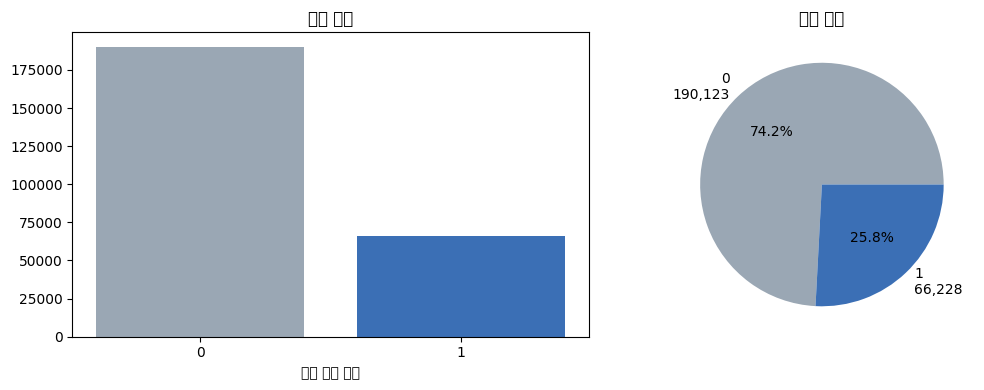

In [7]:
if TARGET in train.columns:
    vc = train[TARGET].value_counts(dropna=False).sort_index()
    rate = train[TARGET].mean()
    print(vc)
    print(f"\n임신 성공률(양성 비율): {rate:.4f}  ({rate*100:.2f}%)")
    print(f"불균형 비율 (실패:성공): {(1-rate)/rate:.2f} : 1")

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].bar(vc.index.astype(str), vc.values, color=["#9aa7b4", "#3b6fb5"])
    ax[0].set_title("타깃 빈도"); ax[0].set_xlabel(TARGET)
    ax[1].pie(vc.values, labels=[f"{i}\n{v:,}" for i, v in vc.items()],
              autopct="%1.1f%%", colors=["#9aa7b4", "#3b6fb5"])
    ax[1].set_title("타깃 비율")
    plt.tight_layout(); plt.show()
else:
    print("train에 타깃 컬럼이 없음 — test 셋이거나 컬럼명을 확인하세요.")

## 6. 결측치 분석 — 이 데이터의 1순위 과제

이 데이터에서 결측은 "랜덤 누락"이 아니라 **구조적**이다. DI 시술에는 배아/난자 관련 컬럼 자체가 의미가 없어 비어 있다. 그래서 결측을 **단순 평균 대치하면 안 되고**, 시술 유형별로 끊어서 봐야 한다.

결측 있는 컬럼 수: 31 / 69

=== 결측률 상위 25 ===
난자 해동 경과일               99.440
PGS 시술 여부               99.248
PGD 시술 여부               99.150
착상 전 유전 검사 사용 여부        98.940
임신 시도 또는 마지막 임신 경과 연수   96.345
배아 해동 경과일               84.252
난자 채취 경과일               22.426
난자 혼합 경과일               20.961
배아 이식 경과일               16.995
미세주입 후 저장된 배아 수          2.454
해동된 배아 수                 2.454
저장된 배아 수                 2.454
미세주입 배아 이식 수             2.454
대리모 여부                   2.454
단일 배아 이식 여부              2.454
착상 전 유전 진단 사용 여부         2.454
배아 생성 주요 이유              2.454
미세주입에서 생성된 배아 수          2.454
이식된 배아 수                 2.454
총 생성 배아 수                2.454
기증 배아 사용 여부              2.454
미세주입된 난자 수               2.454
혼합된 난자 수                 2.454
해동 난자 수                  2.454
수집된 신선 난자 수              2.454
dtype: float64


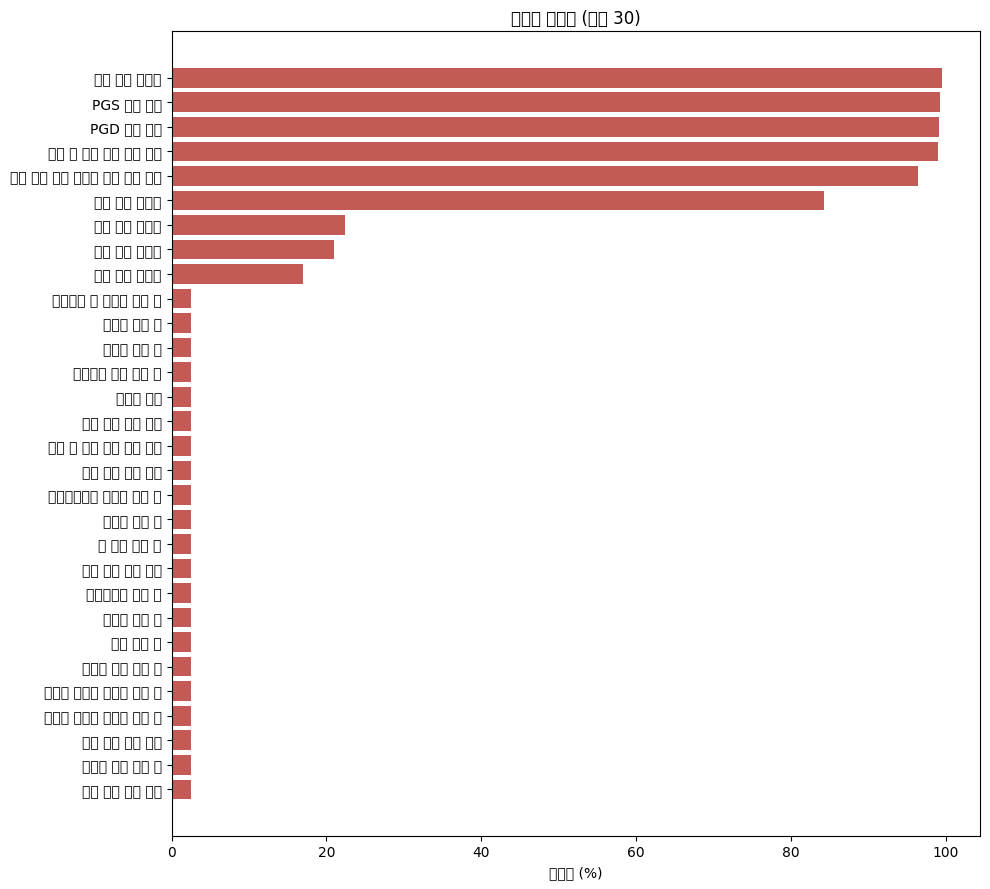

In [8]:
miss = (train.isna().mean()*100).sort_values(ascending=False)
miss = miss[miss > 0]
print(f"결측 있는 컬럼 수: {len(miss)} / {train.shape[1]}")
print("\n=== 결측률 상위 25 ===")
print(miss.head(25))

if len(miss) > 0:
    plt.figure(figsize=(10, max(4, len(miss.head(30))*0.3)))
    top = miss.head(30)[::-1]
    plt.barh(top.index, top.values, color="#c25b56")
    plt.xlabel("결측률 (%)"); plt.title("컬럼별 결측률 (상위 30)")
    plt.tight_layout(); plt.show()

In [9]:
# train vs test 결측률 비교 (분포 시프트 점검)
if test is not None:
    common = [c for c in train.columns if c in test.columns]
    cmp = pd.DataFrame({
        "train_결측%": (train[common].isna().mean()*100).round(2),
        "test_결측%":  (test[common].isna().mean()*100).round(2),
    })
    cmp["차이"] = (cmp["train_결측%"] - cmp["test_결측%"]).abs()
    print("=== train/test 결측률 차이 큰 컬럼 ===")
    print(cmp.sort_values("차이", ascending=False).head(15))
else:
    print("test 셋이 없어 비교 생략")

=== train/test 결측률 차이 큰 컬럼 ===
                  train_결측%  test_결측%    차이
난자 혼합 경과일            20.960    20.630 0.330
난자 채취 경과일            22.430    22.150 0.280
배아 해동 경과일            84.250    84.510 0.260
배아 이식 경과일            16.990    16.930 0.060
저장된 배아 수              2.450     2.420 0.030
미세주입 후 저장된 배아 수       2.450     2.420 0.030
해동된 배아 수              2.450     2.420 0.030
총 생성 배아 수             2.450     2.420 0.030
착상 전 유전 진단 사용 여부      2.450     2.420 0.030
단일 배아 이식 여부           2.450     2.420 0.030
배아 생성 주요 이유           2.450     2.420 0.030
미세주입 배아 이식 수          2.450     2.420 0.030
미세주입된 난자 수            2.450     2.420 0.030
미세주입에서 생성된 배아 수       2.450     2.420 0.030
동결 배아 사용 여부           2.450     2.420 0.030


In [10]:
# ★ 시술 유형(IVF/DI)별 결측 구조 — 핵심
if COL_TRT_TYPE in train.columns:
    grp = train.groupby(COL_TRT_TYPE)
    miss_by_type = grp.apply(lambda g: g.isna().mean()*100).T
    # 유형 간 결측률 차이가 큰 컬럼만 추출
    if miss_by_type.shape[1] >= 2:
        spread = miss_by_type.max(axis=1) - miss_by_type.min(axis=1)
        show = miss_by_type.loc[spread.sort_values(ascending=False).head(20).index]
        print("=== 시술 유형에 따라 결측률이 크게 갈리는 컬럼 (상위 20) ===")
        print(show.round(1))
        print("\n→ 이 컬럼들은 '결측=해당 시술에 비적용'일 가능성이 큼. "
              "유형별 분리 처리 또는 '미적용' 플래그 + 0 대치를 검토.")
    else:
        print(grp.size())

=== 시술 유형에 따라 결측률이 크게 갈리는 컬럼 (상위 20) ===
시술 유형                 DI   IVF
수집된 신선 난자 수      100.000 0.000
파트너 정자와 혼합된 난자 수 100.000 0.000
배아 생성 주요 이유      100.000 0.000
착상 전 유전 진단 사용 여부 100.000 0.000
단일 배아 이식 여부      100.000 0.000
대리모 여부           100.000 0.000
기증 배아 사용 여부      100.000 0.000
기증자 정자와 혼합된 난자 수 100.000 0.000
미세주입된 난자 수       100.000 0.000
총 생성 배아 수        100.000 0.000
해동 난자 수          100.000 0.000
혼합된 난자 수         100.000 0.000
저장된 신선 난자 수      100.000 0.000
미세주입 후 저장된 배아 수  100.000 0.000
해동된 배아 수         100.000 0.000
저장된 배아 수         100.000 0.000
미세주입 배아 이식 수     100.000 0.000
미세주입에서 생성된 배아 수  100.000 0.000
이식된 배아 수         100.000 0.000
동결 배아 사용 여부      100.000 0.000

→ 이 컬럼들은 '결측=해당 시술에 비적용'일 가능성이 큼. 유형별 분리 처리 또는 '미적용' 플래그 + 0 대치를 검토.


## 7. 범주형 변수 — 카디널리티 & 타깃 관계

명목형/이진/순서형 각각을 본다. 특히 **카디널리티(고유값 수)** 가 높은 컬럼은 인코딩 전략(타깃 인코딩 vs 원핫 vs 빈도)을 미리 정해야 한다.

In [11]:
# 명목형 카디널리티
print("=== 명목형 컬럼 카디널리티 ===")
for c in NOMINAL_COLS:
    if c in train.columns:
        print(f"  {c:<22} 고유값 {train[c].nunique():>4}개")

print("\n=== 이진 컬럼 실제 값 분포 (0/1 외 값 섞였는지 점검) ===")
for c in BINARY_COLS[:8]:
    if c in train.columns:
        print(f"  {c}: {dict(train[c].value_counts(dropna=False))}")
print("  ... (앞 8개만 표시)")

=== 명목형 컬럼 카디널리티 ===
  시술 시기 코드               고유값    7개
  시술 유형                  고유값    2개
  특정 시술 유형               고유값   24개
  배란 유도 유형               고유값    4개
  배아 생성 주요 이유            고유값   13개
  난자 출처                  고유값    3개
  정자 출처                  고유값    4개

=== 이진 컬럼 실제 값 분포 (0/1 외 값 섞였는지 점검) ===
  배란 자극 여부: {1: np.int64(197720), 0: np.int64(58631)}
  단일 배아 이식 여부: {0.0: np.int64(191677), 1.0: np.int64(58383), nan: np.int64(6291)}
  착상 전 유전 검사 사용 여부: {nan: np.int64(253633), 1.0: np.int64(2718)}
  착상 전 유전 진단 사용 여부: {0.0: np.int64(246864), nan: np.int64(6291), 1.0: np.int64(3196)}
  남성 주 불임 원인: {0: np.int64(249041), 1: np.int64(7310)}
  남성 부 불임 원인: {0: np.int64(252989), 1: np.int64(3362)}
  여성 주 불임 원인: {0: np.int64(248475), 1: np.int64(7876)}
  여성 부 불임 원인: {0: np.int64(253164), 1: np.int64(3187)}
  ... (앞 8개만 표시)


In [12]:
# 범주형 → 타깃 성공률 (양성률) : 신호가 있는 변수 찾기
def cat_target_rate(col, min_count=30, topn=15):
    if col not in train.columns or TARGET not in train.columns:
        return None
    g = train.groupby(col)[TARGET].agg(["mean", "count"])
    g = g[g["count"] >= min_count].sort_values("mean", ascending=False)
    g.columns = ["성공률", "표본수"]
    return g.head(topn)

base = train[TARGET].mean() if TARGET in train.columns else None
print(f"전체 평균 성공률: {base:.4f}\n")
for c in ["시술 유형", "시술 당시 나이", "난자 출처", "배란 유도 유형"]:
    r = cat_target_rate(c)
    if r is not None:
        print(f"=== {c} 별 성공률 ===")
        print(r, "\n")

전체 평균 성공률: 0.2583

=== 시술 유형 별 성공률 ===
        성공률     표본수
시술 유형              
IVF   0.262  250060
DI    0.129    6291 

=== 시술 당시 나이 별 성공률 ===
           성공률     표본수
시술 당시 나이              
만18-34세  0.323  102476
만35-37세  0.278   57780
만38-39세  0.217   39247
만45-50세  0.168    6918
만40-42세  0.159   37348
만43-44세  0.118   12253
알 수 없음   0.000     329 

=== 난자 출처 별 성공률 ===
         성공률     표본수
난자 출처               
기증 제공  0.315   15769
본인 제공  0.258  234291
알 수 없음 0.129    6291 

=== 배란 유도 유형 별 성공률 ===
             성공률     표본수
배란 유도 유형                
기록되지 않은 시행 0.268  194432
알 수 없음     0.227   61917 



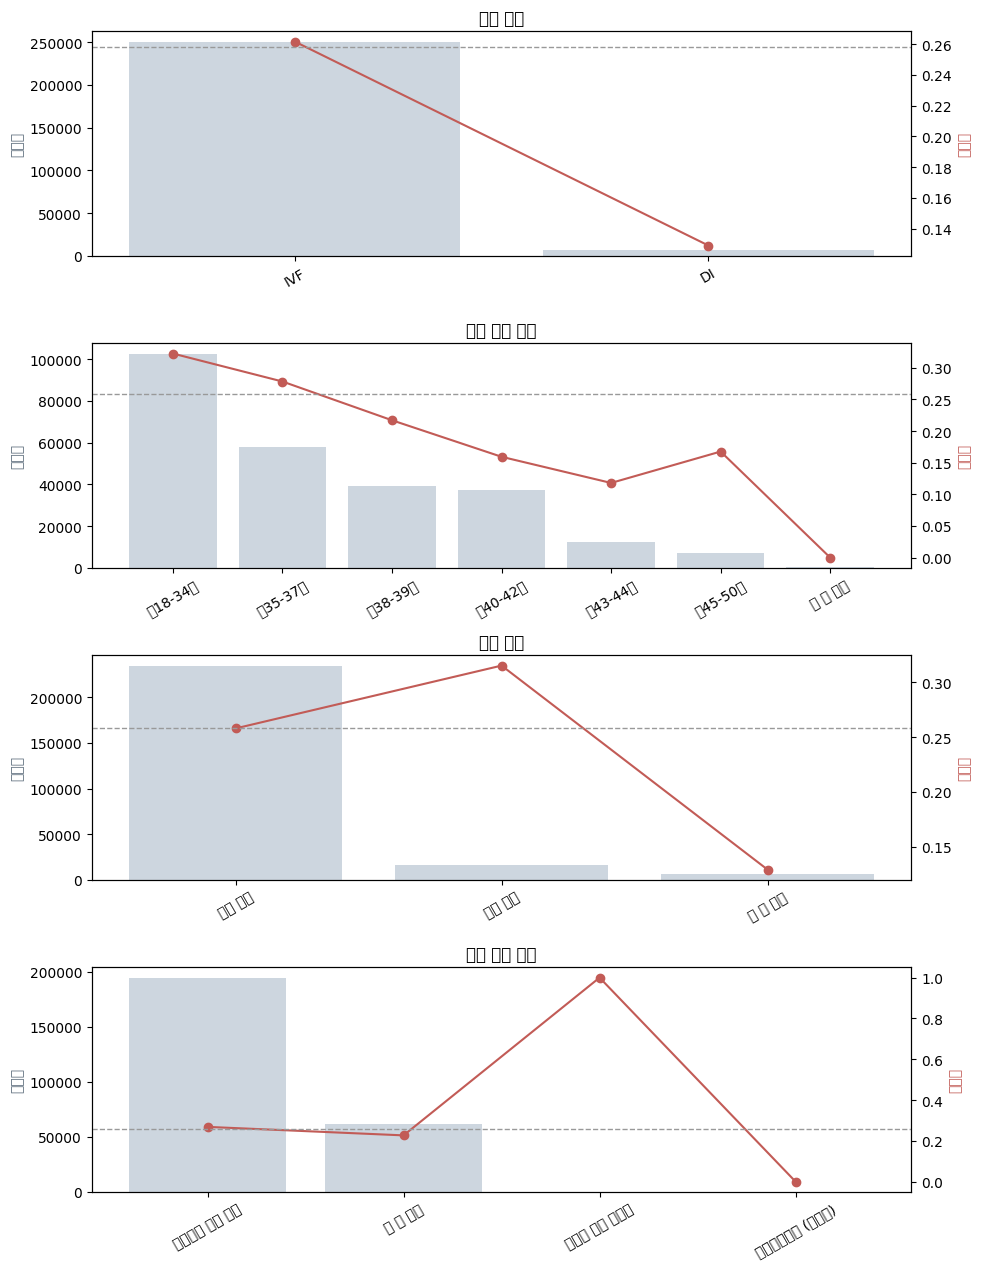

In [13]:
# 주요 범주형 막대그래프 (빈도 + 성공률 오버레이)
plot_cols = [c for c in ["시술 유형", "시술 당시 나이", "난자 출처", "배란 유도 유형"] if c in train.columns]
if plot_cols and TARGET in train.columns:
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 3.2*len(plot_cols)))
    if len(plot_cols) == 1: axes = [axes]
    for ax, c in zip(axes, plot_cols):
        g = train.groupby(c)[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
        ax.bar(g.index.astype(str), g["count"], color="#cdd6df")
        ax.set_ylabel("표본수", color="#5b6b7a")
        ax2 = ax.twinx()
        ax2.plot(g.index.astype(str), g["mean"], "o-", color="#c25b56")
        ax2.axhline(base, ls="--", color="#999", lw=1)
        ax2.set_ylabel("성공률", color="#c25b56")
        ax.set_title(c)
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout(); plt.show()

## 8. 순서형 변수 — 횟수/나이 밴드 처리

`'0회'~'6회 이상'` 같은 밴드는 문자열이지만 **순서**가 있다. 정수로 매핑한 뒤 타깃과의 관계를 본다. (`'6회 이상'`은 상한이 잘린 censored 값이라는 점 기억.)

횟수 컬럼 원본 고유값 예시:
  총 시술 횟수: ['0회', '1회', '2회', '3회', '4회', '5회', '6회 이상']
  클리닉 내 총 시술 횟수: ['0회', '1회', '2회', '3회', '4회', '5회', '6회 이상']
  IVF 시술 횟수: ['0회', '1회', '2회', '3회', '4회', '5회', '6회 이상']


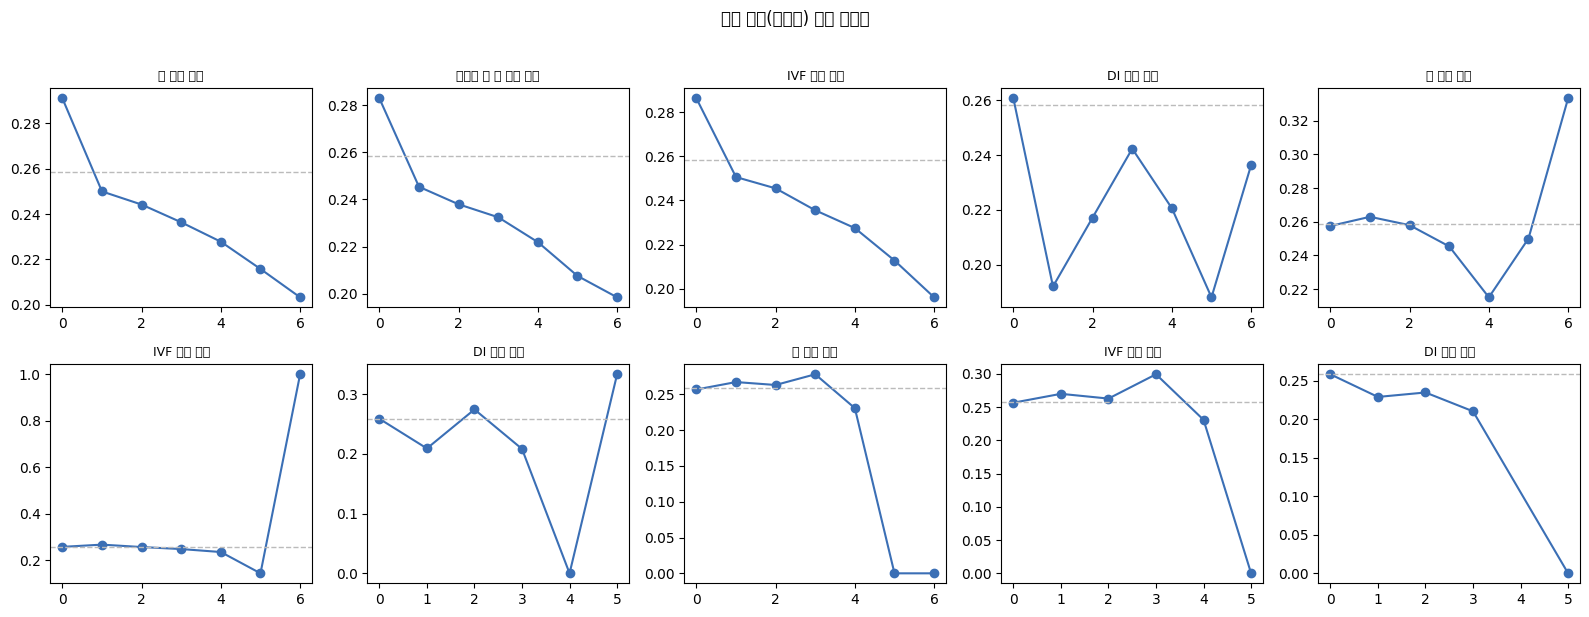

In [14]:
# 횟수 밴드 → 정수 매핑 후 성공률 추세
import re
def parse_count_band(s):
    if pd.isna(s): return np.nan
    s = str(s)
    if "이상" in s:
        m = re.search(r"(\d+)", s); return float(m.group(1)) if m else np.nan
    m = re.search(r"(\d+)", s)
    return float(m.group(1)) if m else np.nan

count_present = [c for c in ORDINAL_COUNT_COLS if c in train.columns]
print("횟수 컬럼 원본 고유값 예시:")
for c in count_present[:3]:
    print(f"  {c}: {sorted(train[c].dropna().unique())}")

if count_present and TARGET in train.columns:
    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    for ax, c in zip(axes.ravel(), count_present):
        tmp = train[[c, TARGET]].copy()
        tmp["_ord"] = tmp[c].map(parse_count_band)
        g = tmp.groupby("_ord")[TARGET].mean()
        ax.plot(g.index, g.values, "o-", color="#3b6fb5")
        ax.axhline(base, ls="--", color="#bbb", lw=1)
        ax.set_title(c, fontsize=9)
    for ax in axes.ravel()[len(count_present):]:
        ax.axis("off")
    plt.suptitle("횟수 밴드(정수화) 대비 성공률", y=1.02)
    plt.tight_layout(); plt.show()

## 9. 수치형 변수 — 분포·이상치·타깃별 차이

배아/난자 개수, 경과일 컬럼들. 0이 많은 zero-inflated 분포, 극단 이상치, 음수(경과일 오류) 등을 점검한다.

In [15]:
num_present = [c for c in NUMERIC_COLS if c in train.columns]
desc = train[num_present].describe().T
desc["결측률%"] = (train[num_present].isna().mean()*100).round(1)
desc["0의비율%"] = ((train[num_present] == 0).mean()*100).round(1)
desc[["count","mean","std","min","50%","max","결측률%","0의비율%"]]

,count,mean,std,min,50%,max,결측률%,0의비율%
임신 시도 또는 마지막 임신 경과 연수,"9,370.000",9.271,3.550,0.000,9.000,20.000,96.300,0.000
총 생성 배아 수,"250,060.000",5.061,4.664,0.000,4.000,51.000,2.500,20.800
미세주입된 난자 수,"250,060.000",4.171,5.626,0.000,0.000,51.000,2.500,49.800
미세주입에서 생성된 배아 수,"250,060.000",2.844,4.095,0.000,0.000,43.000,2.500,51.400
이식된 배아 수,"250,060.000",1.368,0.772,0.000,1.000,3.000,2.500,14.300
미세주입 배아 이식 수,"250,060.000",0.725,0.894,0.000,0.000,3.000,2.500,54.100
저장된 배아 수,"250,060.000",1.186,2.502,0.000,0.000,51.000,2.500,65.100
미세주입 후 저장된 배아 수,"250,060.000",0.613,1.843,0.000,0.000,51.000,2.500,79.700
해동된 배아 수,"250,060.000",0.455,1.415,0.000,0.000,32.000,2.500,81.800
해동 난자 수,"250,060.000",0.046,0.688,0.000,0.000,36.000,2.500,97.000


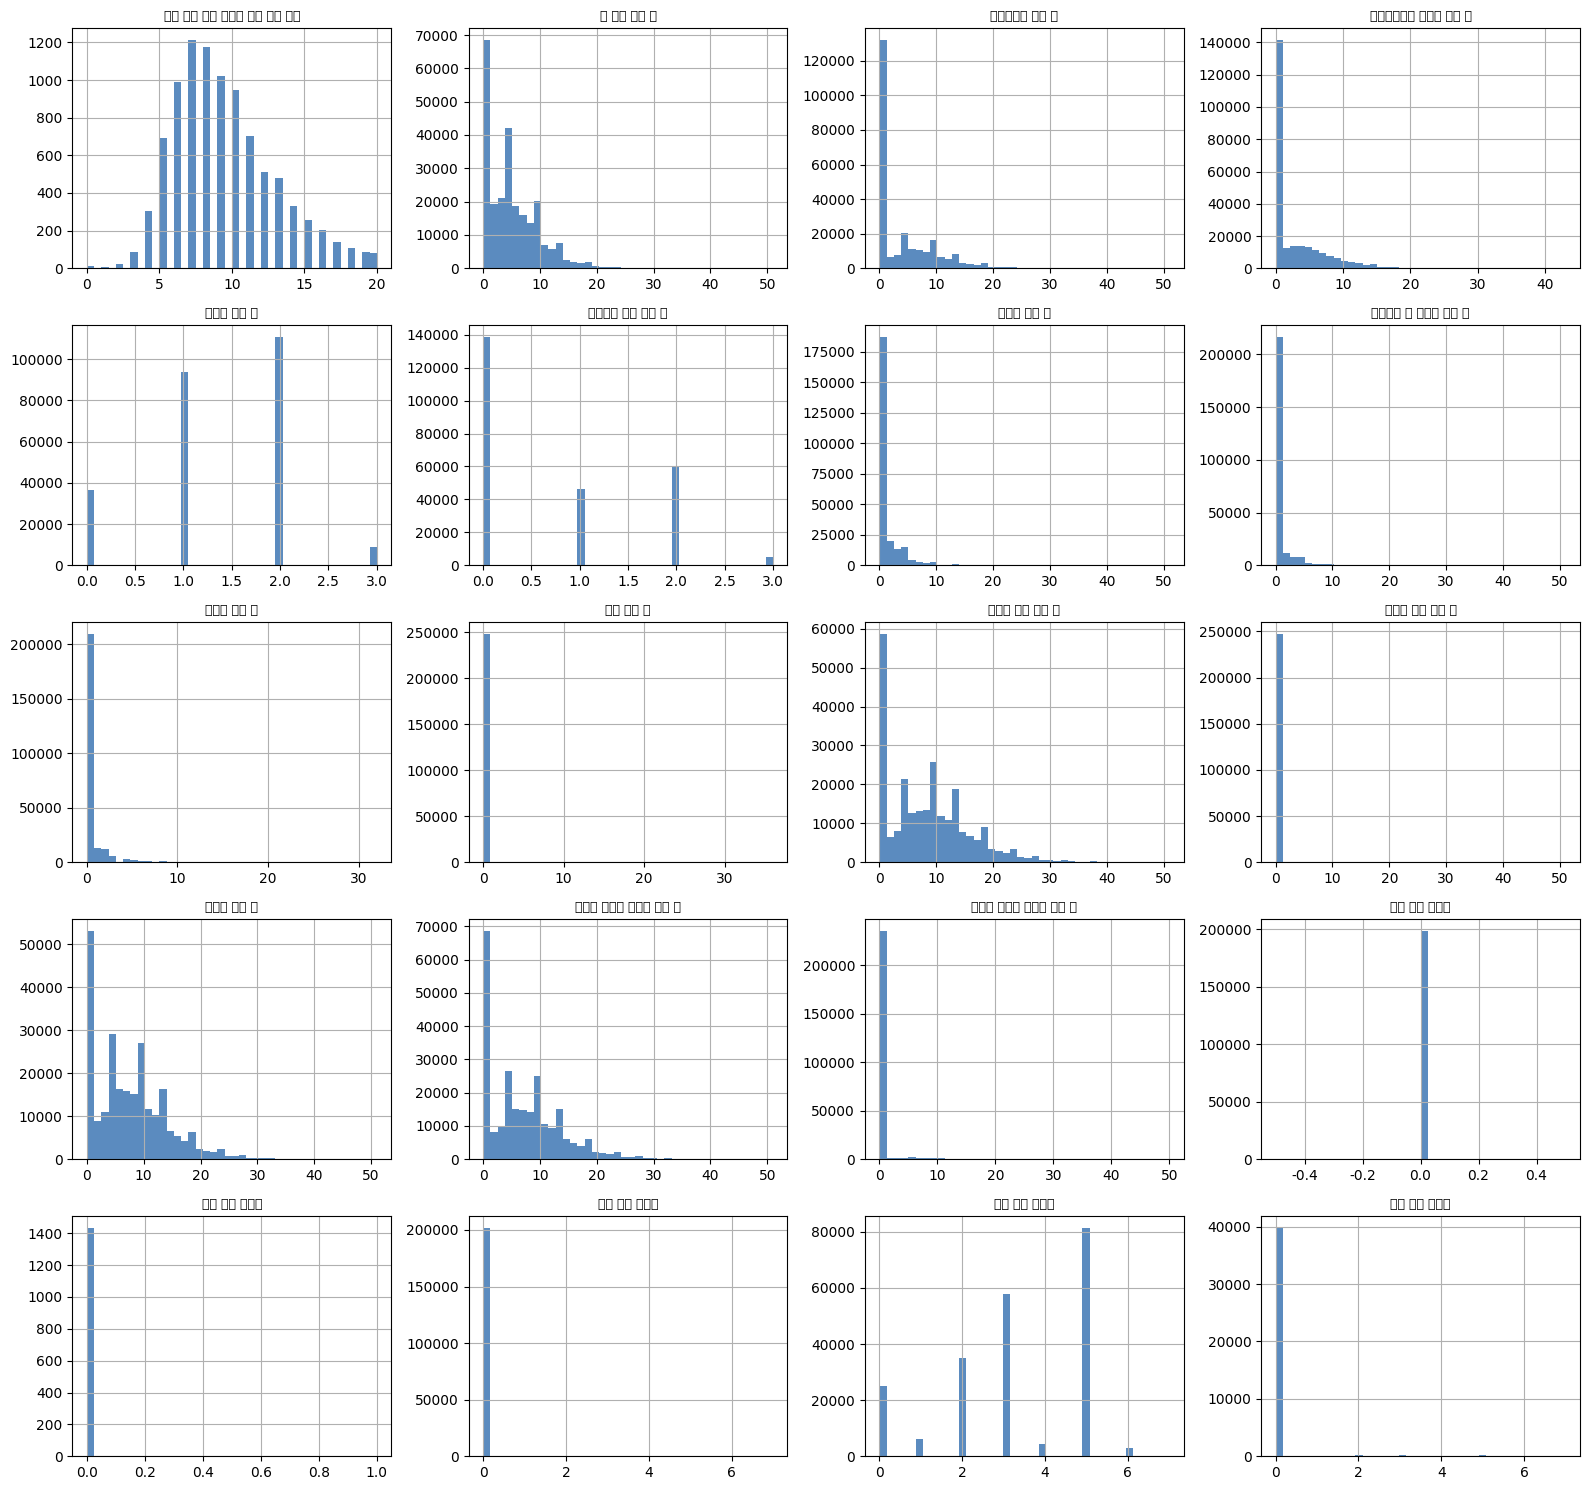

In [16]:
# 수치형 히스토그램
if num_present:
    ncol = 4; nrow = int(np.ceil(len(num_present)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(16, 3*nrow))
    for ax, c in zip(axes.ravel(), num_present):
        train[c].dropna().hist(bins=40, ax=ax, color="#5b8bbf")
        ax.set_title(c, fontsize=9)
    for ax in axes.ravel()[len(num_present):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

In [17]:
# 이상치/오류 점검: 음수값, 극단 상한
print("=== 음수값이 존재하는 수치형 (경과일 등에서 오류 가능) ===")
for c in num_present:
    neg = (train[c] < 0).sum()
    if neg > 0:
        print(f"  {c}: 음수 {neg}건, 최소 {train[c].min()}")
print("(음수 없으면 위에 아무것도 안 나옴)")

print("\n=== 상위 0.1% 극단값 (이상치 후보) ===")
for c in num_present[:8]:
    q999 = train[c].quantile(0.999)
    mx = train[c].max()
    if pd.notna(mx) and pd.notna(q999) and mx > q999:
        print(f"  {c}: 99.9%={q999:.1f}, max={mx:.1f}")

=== 음수값이 존재하는 수치형 (경과일 등에서 오류 가능) ===
(음수 없으면 위에 아무것도 안 나옴)

=== 상위 0.1% 극단값 (이상치 후보) ===
  총 생성 배아 수: 99.9%=27.0, max=51.0
  미세주입된 난자 수: 99.9%=32.0, max=51.0
  미세주입에서 생성된 배아 수: 99.9%=24.0, max=43.0
  저장된 배아 수: 99.9%=22.0, max=51.0
  미세주입 후 저장된 배아 수: 99.9%=19.0, max=51.0


In [18]:
# 타깃별 수치형 분포 차이 (성공/실패 그룹 평균 비교)
if TARGET in train.columns and num_present:
    cmp = train.groupby(TARGET)[num_present].mean().T
    cmp.columns = [f"타깃={c}" for c in cmp.columns]
    if cmp.shape[1] == 2:
        cmp["차이(성공-실패)"] = cmp.iloc[:,1] - cmp.iloc[:,0]
        cmp = cmp.reindex(cmp["차이(성공-실패)"].abs().sort_values(ascending=False).index)
    print("=== 타깃 그룹별 수치형 평균 (차이 큰 순) ===")
    print(cmp.round(2))

=== 타깃 그룹별 수치형 평균 (차이 큰 순) ===
                       타깃=0  타깃=1  차이(성공-실패)
혼합된 난자 수              7.250 8.960      1.700
파트너 정자와 혼합된 난자 수      6.700 8.260      1.560
총 생성 배아 수             4.660 6.210      1.550
수집된 신선 난자 수           8.200 9.580      1.380
미세주입된 난자 수            3.940 4.830      0.900
미세주입에서 생성된 배아 수       2.620 3.460      0.840
배아 이식 경과일             3.090 3.640      0.550
임신 시도 또는 마지막 임신 경과 연수 9.370 8.920     -0.450
이식된 배아 수              1.300 1.570      0.280
저장된 배아 수              1.130 1.340      0.210
미세주입 배아 이식 수          0.690 0.840      0.150
기증자 정자와 혼합된 난자 수      0.500 0.650      0.150
저장된 신선 난자 수           0.120 0.000     -0.120
미세주입 후 저장된 배아 수       0.590 0.680      0.090
해동된 배아 수              0.470 0.420     -0.050
배아 해동 경과일             0.050 0.030     -0.020
해동 난자 수               0.050 0.040     -0.000
난자 혼합 경과일             0.010 0.000     -0.000
난자 해동 경과일             0.000 0.000     -0.000
난자 채취 경과일             0.000 0.000      0.000


## 10. 특수 컬럼 파싱 — `특정 시술 유형` & `배아 생성 주요 이유`

`특정 시술 유형`은 `ICSI / BLASTOCYST`, `ICSI:IVF` 처럼 `/`(복합 방법)와 `:`(세부 조합)로 묶인 문자열이라 그대로 두면 고유값이 폭발한다. 토큰으로 분해해서 어떤 시술 성분이 들어있는지를 멀티-핫으로 푸는 게 정석. `배아 생성 주요 이유`도 복수 선택이라 같은 방식.

In [19]:
# 특정 시술 유형: 원본 카디널리티 → 토큰 분해
if COL_PROC_TYPE in train.columns:
    print(f"'{COL_PROC_TYPE}' 원본 고유값 수: {train[COL_PROC_TYPE].nunique()}")
    print("\n빈도 상위 15개 원본 값:")
    print(train[COL_PROC_TYPE].value_counts().head(15))

    def tokenize(s):
        if pd.isna(s): return []
        return [t.strip() for t in re.split(r"[/:]", str(s)) if t.strip()]

    tokens = train[COL_PROC_TYPE].apply(tokenize)
    from collections import Counter
    cnt = Counter(t for toks in tokens for t in toks)
    print("\n분해된 개별 시술 토큰 빈도:")
    for tok, n in cnt.most_common():
        print(f"  {tok:<14} {n:>7,}")
    print(f"\n→ 고유 토큰 {len(cnt)}개. 멀티-핫(있다/없다) 피처로 펼치면 됨.")

'특정 시술 유형' 원본 고유값 수: 24

빈도 상위 15개 원본 값:
특정 시술 유형
ICSI                  122368
IVF                    91755
Unknown                26939
IUI                     6100
ICSI:ICSI               2314
ICSI / BLASTOCYST       1609
IVF / BLASTOCYST        1248
IVF:IVF                 1146
ICSI:IVF                 873
ICSI / AH                769
IVF:ICSI                 392
IVF / AH                 319
ICSI:Unknown             207
IVF:Unknown              100
ICI                       96
Name: count, dtype: int64

분해된 개별 시술 토큰 빈도:
  ICSI           130,862
  IVF             96,991
  Unknown         27,248
  IUI              6,100
  BLASTOCYST       2,878
  AH               1,094
  ICI                 96
  Generic DI          71
  IVI                 23
  FER                  3
  GIFT                 2

→ 고유 토큰 11개. 멀티-핫(있다/없다) 피처로 펼치면 됨.


In [20]:
# 배아 생성 주요 이유: 복수 선택 → 토큰 빈도
if COL_EMBRYO_RSN in train.columns:
    print(f"'{COL_EMBRYO_RSN}' 원본 고유값 수: {train[COL_EMBRYO_RSN].nunique()}")
    print(train[COL_EMBRYO_RSN].value_counts(dropna=False).head(15))
    def tok2(s):
        if pd.isna(s): return []
        return [t.strip() for t in re.split(r"[,/]", str(s)) if t.strip()]
    from collections import Counter
    c2 = Counter(t for toks in train[COL_EMBRYO_RSN].apply(tok2) for t in toks)
    print("\n분해 토큰 빈도:")
    for tok, n in c2.most_common():
        print(f"  {tok:<12} {n:>7,}")

'배아 생성 주요 이유' 원본 고유값 수: 13
배아 생성 주요 이유
현재 시술용                 233732
배아 저장용                   9192
NaN                      6291
기증용, 현재 시술용              3784
난자 저장용                   1959
기증용                      1108
기증용, 배아 저장용               125
배아 저장용, 현재 시술용             83
기증용, 난자 저장용                44
기증용, 배아 저장용, 현재 시술용        20
난자 저장용, 배아 저장용              6
난자 저장용, 현재 시술용              5
연구용, 현재 시술용                 1
난자 저장용, 배아 저장용, 연구용         1
Name: count, dtype: int64

분해 토큰 빈도:
  현재 시술용       237,625
  배아 저장용         9,427
  기증용            5,081
  난자 저장용         2,015
  연구용                2


## 11. 수치형 상관관계 — 다중공선성 점검

배아/난자 개수 컬럼들은 서로 강하게 묶일 수 있다(예: 생성 배아 ↔ 이식 배아). 트리 모델엔 큰 문제 아니지만, 파생 피처 만들 때 중복을 알고 있어야 한다.

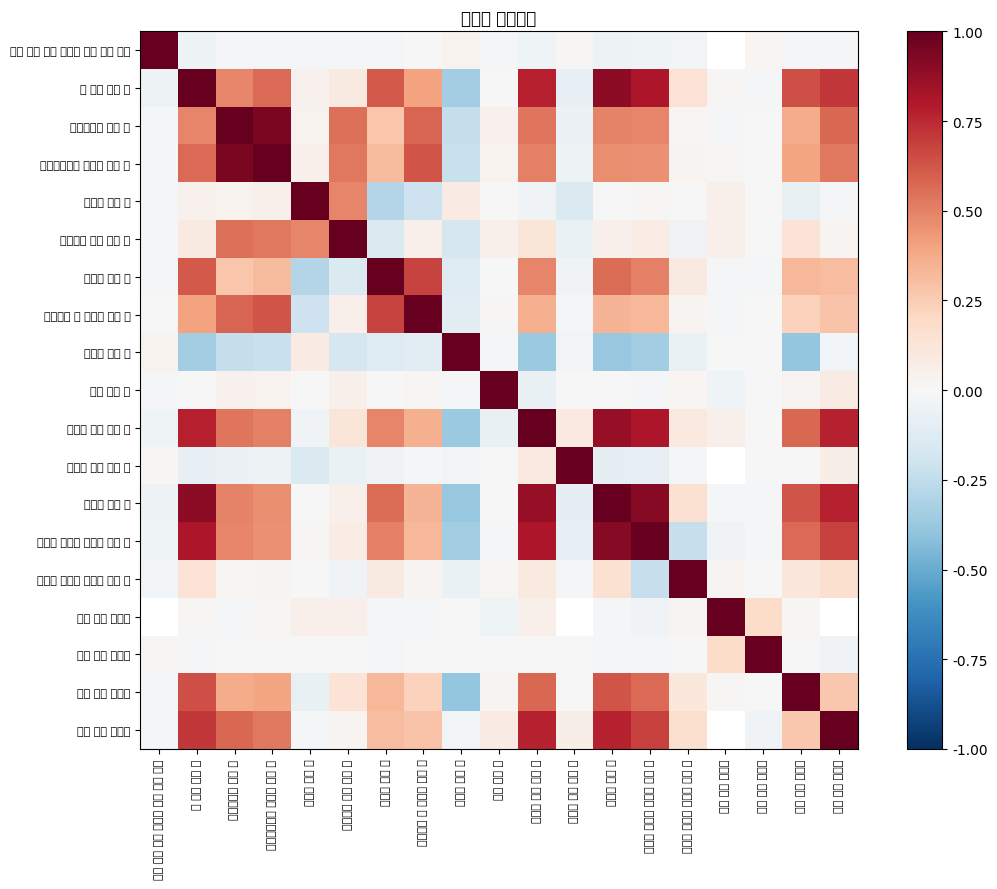

=== |상관| ≥ 0.6 쌍 ===
  +0.940  미세주입된 난자 수  ↔  미세주입에서 생성된 배아 수
  +0.913  혼합된 난자 수  ↔  파트너 정자와 혼합된 난자 수
  +0.892  총 생성 배아 수  ↔  혼합된 난자 수
  +0.872  수집된 신선 난자 수  ↔  혼합된 난자 수
  +0.811  총 생성 배아 수  ↔  파트너 정자와 혼합된 난자 수
  +0.810  수집된 신선 난자 수  ↔  파트너 정자와 혼합된 난자 수
  +0.779  총 생성 배아 수  ↔  수집된 신선 난자 수
  +0.771  혼합된 난자 수  ↔  배아 해동 경과일
  +0.766  수집된 신선 난자 수  ↔  배아 해동 경과일
  +0.704  총 생성 배아 수  ↔  배아 해동 경과일
  +0.680  파트너 정자와 혼합된 난자 수  ↔  배아 해동 경과일
  +0.673  저장된 배아 수  ↔  미세주입 후 저장된 배아 수
  +0.648  총 생성 배아 수  ↔  배아 이식 경과일
  +0.626  혼합된 난자 수  ↔  배아 이식 경과일
  +0.625  미세주입에서 생성된 배아 수  ↔  미세주입 후 저장된 배아 수
  +0.611  총 생성 배아 수  ↔  저장된 배아 수


In [21]:
num_for_corr = [c for c in num_present if train[c].nunique() > 1]
if len(num_for_corr) >= 2:
    corr = train[num_for_corr].corr()
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(num_for_corr))); ax.set_xticklabels(num_for_corr, rotation=90, fontsize=8)
    ax.set_yticks(range(len(num_for_corr))); ax.set_yticklabels(num_for_corr, fontsize=8)
    fig.colorbar(im, fraction=0.046)
    ax.set_title("수치형 상관행렬")
    plt.tight_layout(); plt.show()

    # 강한 상관쌍
    pairs = []
    for i in range(len(num_for_corr)):
        for j in range(i+1, len(num_for_corr)):
            v = corr.iloc[i, j]
            if abs(v) >= 0.6:
                pairs.append((num_for_corr[i], num_for_corr[j], round(v, 3)))
    print("=== |상관| ≥ 0.6 쌍 ===")
    for a, b, v in sorted(pairs, key=lambda x: -abs(x[2])):
        print(f"  {v:+.3f}  {a}  ↔  {b}")

## 12. 정리 — 전처리 To-Do (다음 노트북으로)

이 EDA에서 드러난 것들을 전처리 작업 항목으로 정리. 실제 출력값을 보고 체크하면서 채워나가면 된다.

**A. 결측 처리 (최우선)**
- [ ] `시술 유형(IVF/DI)`별로 결측 구조가 다른 컬럼 → "미적용" 의미인지 확인 후, `_결측여부` 플래그 + 0 대치 vs 유형별 분리
- [ ] train/test 결측률 차이 큰 컬럼 점검 (분포 시프트 → 검증 신뢰도)

**B. 인코딩**
- [ ] 횟수 밴드(`'0회'~'6회 이상'`) → 순서형 정수 매핑 (`6회 이상`은 censored 인지)
- [ ] 나이 밴드 → 순서형 정수
- [ ] 이진 플래그 → 0/1 정합성 (혹시 섞인 결측/이상값)
- [ ] 명목형 → 카디널리티 기준으로 원핫 / 빈도 / 타깃 인코딩 선택

**C. 특수 컬럼**
- [ ] `특정 시술 유형` → `/`·`:` 토큰 분해 후 멀티-핫
- [ ] `배아 생성 주요 이유` → 복수 선택 멀티-핫

**D. 수치형**
- [ ] 음수 경과일 등 오류값 처리
- [ ] 극단 이상치 클리핑/로그 변환 검토 (zero-inflated 분포)
- [ ] 강한 상관쌍에서 파생 피처(비율 등) 설계

**E. 검증 설계**
- [ ] 클래스 불균형 → `StratifiedKFold`, 평가지표 확정(대회 규정의 metric 확인 — AUC 가능성 높음)

> 다음 단계: 위 To-Do를 그대로 옮긴 **전처리 노트북**을 만들면 된다. 원하면 이어서 같이 짜자.